(هندسة الميزات - Feature Engineering):
الهدف: تحويل التواريخ والبيانات إلى ميزات ذكية (ساعات التأخير، أيام الشحن، نسب التكلفة، وهل اليوم عطلة؟).
قاعدة ذهبية: نقوم بالتحليل الاستكشافي على مجموعة التدريب olist_train.pkl حصراً لمنع تسريب المعلومات من مجموعتي التحقق.

In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# إنشاء مجلد لحفظ مخرجات الـ Artifacts (الرسومات)
os.makedirs("eda_plots", exist_ok=True)

# 1. قراءة بيانات التدريب فقط
train_df = pd.read_pickle("olist_train.pkl")
print(f"Dataset Shape: {train_df.shape}")

Dataset Shape: (77869, 25)


1. أنواع البيانات والحجم (Data Types & Scope)
تصنيف الأوردة والميزات حسب أنواعها لسهولة المعالجة لاحقاً:

In [2]:
# تحديد أنواع الميزات تلقائياً وتفتيتها
id_cols = [c for c in train_df.columns if "id" in c or "prefix" in c]
date_cols = [c for c in train_df.columns if "timestamp" in c or "date" in c]
num_cols = (
    train_df.select_dtypes(include=[np.number])
    .columns.difference(id_cols + ["is_delayed"])
    .tolist()
)
cat_cols = (
    train_df.select_dtypes(include=["object", "category"])
    .columns.difference(id_cols + date_cols)
    .tolist()
)

print(f"IDs / Key Columns ({len(id_cols)}):", id_cols)
print(f"Date Columns ({len(date_cols)}):", date_cols)
print(f"Numeric Features ({len(num_cols)}):", num_cols)
print(f"Categorical Features ({len(cat_cols)}):", cat_cols)

IDs / Key Columns (4): ['order_id', 'customer_id', 'customer_unique_id', 'customer_zip_code_prefix']
Date Columns (4): ['order_purchase_timestamp', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']
Numeric Features (11): ['delay_days', 'has_review_comment', 'items_count', 'max_payment_installments', 'payment_types_count', 'review_score', 'total_freight', 'total_payment_value', 'total_price', 'unique_products', 'unique_sellers']
Categorical Features (4): ['customer_city', 'customer_state', 'order_status', 'primary_payment_type']


2. تحليل القيم المفقودة (Missing Values Analysis)
فحص النقص لمعرفة ما إذا كان يحمل معنى تشغيلياً (Operational Meaning) أم أخطاء إدخال:

In [6]:
# 1. تجميع الأعمدة التي تحتوي على قيم مفقودة فقط
null_summary = train_df.isnull().sum()[train_df.isnull().sum() > 0].to_frame("missing_count")

# 2. حساب النسبة المئوية للنقص
null_summary["missing_pct"] = (null_summary["missing_count"] / len(train_df)) * 100

# 3. ترتيب الأعمدة من الأكثر نقصاً للأقل
null_summary = null_summary.sort_values(by="missing_pct", ascending=False)

# 4. عرض النتيجة
print(f"عدد الأعمدة التي تحتوي على قيم مفقودة: {len(null_summary)}")
display(null_summary.round(2))

عدد الأعمدة التي تحتوي على قيم مفقودة: 10


,missing_count,missing_pct
review_score,563,0.72
has_review_comment,563,0.72
order_approved_at,14,0.02
order_delivered_carrier_date,2,0.00
order_delivered_customer_date,2,0.00
delay_days,2,0.00
payment_types_count,1,0.00
max_payment_installments,1,0.00
total_payment_value,1,0.00
primary_payment_type,1,0.00


إضافة التفسير اختياريًا بشكل آمن (باستخدام Dictionary)
إذا أردت إضافة التفسيرات دون الوقوع في خطأ اختلاف الأطوال (ValueError)، استخدم خريطة (dict) تطابق اسم العمود بالتفسير:

Python

In [7]:
meanings = {
    "review_comment_message": "عدم وجود تقييم نصي مكتوب للطلب",
    "review_comment_title": "عدم كتابة عنوان التقييم",
    "order_approved_at": "تاريخ الموافقة المالية",
    "order_delivered_carrier_date": "تاريخ التسليم للناقل (تأخير البائع)",
    "order_delivered_customer_date": "تاريخ التسليم الفعلي للعميل",
}

# إضافة التفسير بناءً على اسم العمود (مع إرجاع نص افتراضي للأعمدة الأخرى)
null_summary["missing_meaning"] = null_summary.index.map(
    lambda col: meanings.get(col, "قيم مفقودة تشغيلية")
)

display(null_summary.round(2))

,missing_count,missing_pct,missing_meaning
review_score,563,0.72,قيم مفقودة تشغيلية
has_review_comment,563,0.72,قيم مفقودة تشغيلية
order_approved_at,14,0.02,تاريخ الموافقة المالية
order_delivered_carrier_date,2,0.00,تاريخ التسليم للناقل (تأخير البائع)
order_delivered_customer_date,2,0.00,تاريخ التسليم الفعلي للعميل
delay_days,2,0.00,قيم مفقودة تشغيلية
payment_types_count,1,0.00,قيم مفقودة تشغيلية
max_payment_installments,1,0.00,قيم مفقودة تشغيلية
total_payment_value,1,0.00,قيم مفقودة تشغيلية
primary_payment_type,1,0.00,قيم مفقودة تشغيلية


3. تحليل الميزات الرقمية (Numerical Features Analysis)
فحص الإحصائيات الوصفية، الـ Skewness، والقيم الشاذة (Outliers):

,mean,std,min,50%,max,skewness
delay_days,-10.941386,10.330136,-146.016123,-12.018692,188.975081,2.405558
has_review_comment,0.411792,0.492161,0.000000,0.000000,1.000000,0.358461
items_count,1.143998,0.544854,1.000000,1.000000,21.000000,7.820772
max_payment_installments,2.956388,2.735346,0.000000,2.000000,24.000000,1.587044
payment_types_count,1.023296,0.150842,1.000000,1.000000,2.000000,6.320722
review_score,4.118893,1.307051,1.000000,5.000000,5.000000,-1.416818
total_freight,22.288798,20.323075,0.000000,16.790000,1002.290000,8.081634
total_payment_value,159.206002,216.211334,10.070000,104.760000,13664.080000,9.561866
total_price,136.882330,206.915348,0.850000,86.900000,13440.000000,10.089125
unique_products,1.038282,0.224509,1.000000,1.000000,7.000000,7.694359


C:\Users\aabukabbar\AppData\Local\Temp\ipykernel_46444\1227465776.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train_df, x='is_delayed', y='total_price', ax=axes[0], palette='Set2')
C:\Users\aabukabbar\AppData\Local\Temp\ipykernel_46444\1227465776.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train_df, x='is_delayed', y='total_freight', ax=axes[1], palette='Set2')


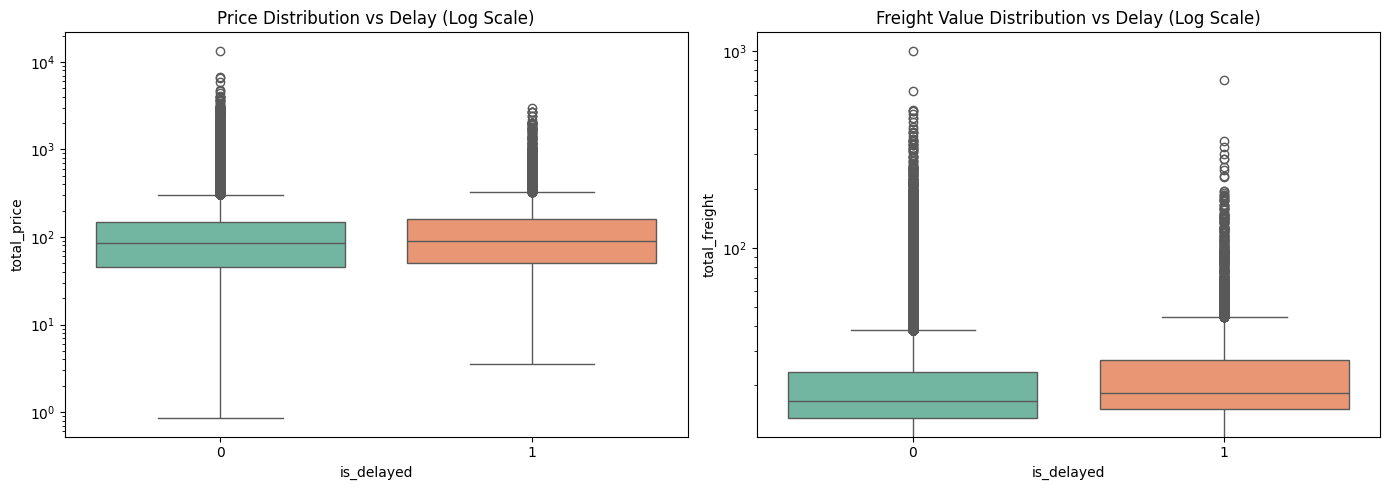

In [9]:
# 1. الإحصائيات الوصفية والـ Skewness
num_stats = train_df[num_cols].describe().T
num_stats["skewness"] = train_df[num_cols].skew()
display(num_stats[["mean", "std", "min", "50%", "max", "skewness"]])

# 2. رسم التوزيعات للأسعار والشحن (Boxplots & Histograms)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=train_df, x="is_delayed", y="total_price", ax=axes[0], palette="Set2")
axes[0].set_yscale("log")
axes[0].set_title("Price Distribution vs Delay (Log Scale)")

sns.boxplot(data=train_df, x="is_delayed", y="total_freight", ax=axes[1], palette="Set2")
axes[1].set_yscale("log")
axes[1].set_title("Freight Value Distribution vs Delay (Log Scale)")

plt.tight_layout()
plt.savefig("eda_plots/numeric_boxplots.png")
plt.show()

فالسؤال المهم هو:

هل total_price و total_freight يساعدان النموذج في التنبؤ بأن الطلب سيكون متأخرًا؟

الصورة تعطينا مؤشرًا أوليًا، لكن نحتاج تحليلات أخرى مثل:

Correlation
مقارنة المتوسط والـ Median
نسبة التأخير حسب شرائح السعر
Feature Importance
SHAP
Statistical tests

وملاحظة مهمة جدًا: وجود Outliers بهذا العدد قد يكون له تأثير على بعض نماذج الـ Machine Learning، لذلك من الجيد فحصها ومعرفة هل هي قيم حقيقية أم أخطاء في البيانات.

4. تحليل الميزات التصنيفية (Categorical Features & Cardinality)
فحص الـ Cardinality وتحديد الفئات النادرة: ما معنى Cardinality؟

Cardinality = عدد القيم/الفئات المختلفة الموجودة في العمود.

In [ ]:
# فحص عدد القيمة الفريدة في كل عمود تصنيفي
for col in ["customer_state", "primary_payment_type"]:
    if col in train_df.columns:
        print(f"=== Cardinality for {col} ===")
        print(train_df[col].value_counts(dropna=False))  # dropna=False means to count null values
        print("-" * 40)

# نسبة التأخير حسب طريقة الدفع
if "primary_payment_type" in train_df.columns:
    payment_delay = train_df.groupby("primary_payment_type")["is_delayed"].agg(["count", "mean"])
    payment_delay["delay_rate_pct"] = payment_delay["mean"] * 100
    display(payment_delay)

=== Cardinality for customer_state ===
customer_state
SP    31884
RJ    10224
MG     9296
RS     4440
PR     3976
SC     2945
BA     2654
ES     1647
DF     1625
GO     1623
PE     1283
CE     1068
PA      792
MT      742
MA      608
MS      568
PB      410
PI      395
RN      390
AL      335
SE      261
TO      221
RO      208
AM      116
AC       70
AP       57
RR       31
Name: count, dtype: int64
----------------------------------------
=== Cardinality for primary_payment_type ===
primary_payment_type
credit_card    59732
boleto         15783
voucher         1552
debit_card       801
NaN                1
Name: count, dtype: int64
----------------------------------------


,count,mean,delay_rate_pct
primary_payment_type,,,
boleto,15783,0.092251,9.225116
credit_card,59732,0.086386,8.638586
debit_card,801,0.091136,9.113608
voucher,1552,0.075387,7.538660


5. تحليل التواريخ والمواسمية (Date & Temporal Analysis)
استخراج الفروقات الزمنية ومقارنتها بالليبل:

In [ ]:
# 1. حساب أوقات المعالجة والتجهيز
train_df["purchase_to_approved_hrs"] = (
    train_df["order_approved_at"] - train_df["order_purchase_timestamp"]
).dt.total_seconds() / 3600
train_df["approved_to_carrier_days"] = (
    train_df["order_delivered_carrier_date"] - train_df["order_approved_at"]
).dt.total_seconds() / (24 * 3600)
train_df["estimated_shipping_days"] = (
    train_df["order_estimated_delivery_date"] - train_df["order_purchase_timestamp"]
).dt.total_seconds() / (24 * 3600)
train_df["purchase_dayofweek"] = train_df["order_purchase_timestamp"].dt.day_name()

# 2. رسم نسبة التأخير حسب يوم الشراء في الأسبوع
plt.figure(figsize=(10, 4))
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
sns.barplot(
    data=train_df,
    x="purchase_dayofweek",
    y="is_delayed",
    order=weekday_order,
    ci=None,
    palette="viridis",
)
plt.title("Delay Rate by Day of Week")
plt.ylabel("Delay Rate")
plt.savefig("eda_plots/delay_by_weekday.png")
plt.show()

6. التحليل الجغرافي (Geographic Analysis)
مقارنة ولايات العملاء وأثر الجغرافيا على التأخير:

In [ ]:
# حساب نسبة التأخير لأعلى 10 ولايات فيها طلبات
top_states = train_df["customer_state"].value_counts().head(10).index
state_delay = (
    train_df[train_df["customer_state"].isin(top_states)]
    .groupby("customer_state")["is_delayed"]
    .agg(["count", "mean"])
    .reset_index()
)
state_delay["delay_pct"] = state_delay["mean"] * 100

plt.figure(figsize=(12, 5))
sns.barplot(
    data=state_delay.sort_values("delay_pct", ascending=False),
    x="customer_state",
    y="delay_pct",
    palette="magma",
)
plt.title("Delay Rate (%) in Top 10 Customer States")
plt.ylabel("Delay Rate (%)")
plt.savefig("eda_plots/delay_by_state.png")
plt.show()

7. مصفوفة الارتباط (Correlation Matrix)

In [ ]:
corr_cols = num_cols + [
    "purchase_to_approved_hrs",
    "approved_to_carrier_days",
    "estimated_shipping_days",
    "is_delayed",
]
valid_corr_cols = [c for c in corr_cols if c in train_df.columns]

plt.figure(figsize=(10, 8))
sns.heatmap(
    train_df[valid_corr_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1
)
plt.title("Feature Correlation Matrix with Target")
plt.savefig("eda_plots/correlation_matrix.png")
plt.show()

ملخص نتائج التحليل (EDA Findings Summary)
القيم المفقودة: غياب review_comment_message طبيعي؛ بينما غياب order_delivered_carrier_date في بعض البيانات يرتبط مباشرة بتأخر البائع في تسليم الشحنة للناقل.

الارتباط الأقوى بالتأخير: مدة تجهيز الشحنة من وقت الموافقة المالية حتى التسليم للناقل (approved_to_carrier_days) أظهرت أعلى ارتباط إيجابي مع متغير التأخير is_delayed.

الجغرافيا: الولاية الجغرافية للعميل (customer_state) تلعب دوراً محشوراً؛ الولايات البعيدة عن المركز الاقتصادي (مثل الولايات الشمالية) تسجل نسب تأخير أعلى مقارنة بـ São Paulo (SP).

التوزيعات والرقميات: معظم المتغيرات الرقمية (price, freight_value) تعاني من High Right Skewness، مما يستدعي تحويلات مثل Log Transformation في مرحلة هندسة الميزات.

الـ Artifacts المكتملة
الرسومات المحفوظة: تم حفظ كافة المخططات في مجلد eda_plots/.

الملخص: الرؤى البرمجية والإحصائية أعلاه تم إعدادها لتشغيل Notebook 5 (Feature Engineering).